<a href="https://colab.research.google.com/github/Hakan-AKILLI/Anomaly-Detection-with-SMOTE/blob/main/SMOTE_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab'a hoş geldiniz.

Ağ trafik logları yükleniyor...
Veri seti başarıyla yüklendi!

Ağ Trafiği Sınıf Dağılımı:
Attack_Category
Normal                67343
DoS                   45927
Probe (Tarama)        11656
R2L (Sızma)             995
U2R (Root Yetkisi)       52
Name: count, dtype: int64

En tehlikeli sızma saldırılarının (U2R ve R2L) tüm trafiğe oranı: Sadece % 0.831!


/tmp/ipykernel_31953/1702536813.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attack_Category', data=df, order=kategori_sayilari.index, palette='magma')


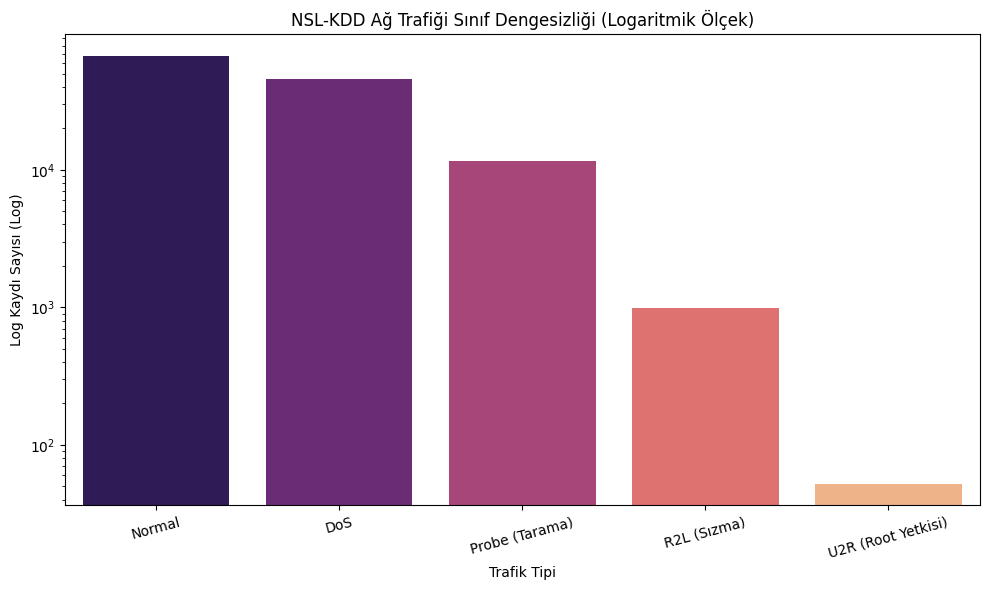

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NSL-KDD veri setinin standart ağ paketi özellikleri (41 özellik + 1 etiket)
kolonlar = ["duration", "protocol_type", "service", "flag", "src_bytes",
            "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
            "num_failed_logins", "logged_in", "num_compromised", "root_shell",
            "su_attempted", "num_root", "num_file_creations", "num_shells",
            "num_access_files", "num_outbound_cmds", "is_host_login",
            "is_guest_login", "count", "srv_count", "serror_rate",
            "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
            "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
            "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
            "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
            "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
            "dst_host_srv_rerror_rate", "label"]

# Veriyi yüklüyoruz (Dosya adını Colab'a yüklediğin isimle eşleştir, genelde KDDTrain+.txt'dir)
# NSL-KDD'nin son sütununda fazladan bir 'zorluk derecesi' (difficulty level) olabilir, onu dışarıda bırakıyoruz.
print("Ağ trafik logları yükleniyor...")
df = pd.read_csv('KDDTrain+.txt', names=kolonlar, usecols=range(42))
print("Veri seti başarıyla yüklendi!\n")

# Alt saldırı türlerini 4 ana siber tehdit kategorisine ayırıyoruz
saldiri_kategorileri = {
    'normal': 'Normal',
    'neptune': 'DoS', 'smurf': 'DoS', 'pod': 'DoS', 'teardrop': 'DoS', 'land': 'DoS', 'back': 'DoS', 'apache2': 'DoS', 'udpstorm': 'DoS', 'processtable': 'DoS', 'mailbomb': 'DoS',
    'satan': 'Probe (Tarama)', 'ipsweep': 'Probe (Tarama)', 'nmap': 'Probe (Tarama)', 'portsweep': 'Probe (Tarama)', 'mscan': 'Probe (Tarama)', 'saint': 'Probe (Tarama)',
    'guess_passwd': 'R2L (Sızma)', 'ftp_write': 'R2L (Sızma)', 'imap': 'R2L (Sızma)', 'phf': 'R2L (Sızma)', 'multihop': 'R2L (Sızma)', 'warezmaster': 'R2L (Sızma)', 'warezclient': 'R2L (Sızma)', 'spy': 'R2L (Sızma)', 'xlock': 'R2L (Sızma)', 'xsnoop': 'R2L (Sızma)', 'snmpguess': 'R2L (Sızma)', 'snmpgetattack': 'R2L (Sızma)', 'httptunnel': 'R2L (Sızma)', 'sendmail': 'R2L (Sızma)', 'named': 'R2L (Sızma)',
    'buffer_overflow': 'U2R (Root Yetkisi)', 'loadmodule': 'U2R (Root Yetkisi)', 'rootkit': 'U2R (Root Yetkisi)', 'perl': 'U2R (Root Yetkisi)', 'sqlattack': 'U2R (Root Yetkisi)', 'xterm': 'U2R (Root Yetkisi)', 'ps': 'U2R (Root Yetkisi)'
}

# Etiketleri ana kategorilere eşleyelim
df['Attack_Category'] = df['label'].map(lambda x: saldiri_kategorileri.get(x, 'Bilinmeyen (0-Day)'))

# Dağılımı hesaplayıp ekrana yazdıralım
kategori_sayilari = df['Attack_Category'].value_counts()
print("Ağ Trafiği Sınıf Dağılımı:")
print(kategori_sayilari)

# U2R ve R2L gibi nadir ama kritik saldırıların oranını hesaplayalım
toplam_kayit = len(df)
nadir_saldirilar = kategori_sayilari.get('U2R (Root Yetkisi)', 0) + kategori_sayilari.get('R2L (Sızma)', 0)
print(f"\nEn tehlikeli sızma saldırılarının (U2R ve R2L) tüm trafiğe oranı: Sadece % {(nadir_saldirilar / toplam_kayit) * 100:.3f}!")

# Proje Raporuna koyacağımız o meşhur Sınıf Dengesizliği Grafiği
plt.figure(figsize=(10, 6))
# Fark çok devasa olduğu için Y eksenini Logaritmik yapıyoruz ki nadir saldırılar grafikte görülebilsin
sns.countplot(x='Attack_Category', data=df, order=kategori_sayilari.index, palette='magma')
plt.title('NSL-KDD Ağ Trafiği Sınıf Dengesizliği (Logaritmik Ölçek)')
plt.xlabel('Trafik Tipi')
plt.ylabel('Log Kaydı Sayısı (Log)')
plt.yscale('log')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# Dosyayı hiçbir sütun ismi vermeden ve hiçbir ekleme yapmadan okuyoruz
#ham_veri = pd.read_csv('KDDTrain+.txt', header=None)

# İlk 5 satırı ekrana yazdırıyoruz
df.sample(10)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,Attack_Category
70405,0,udp,domain_u,SF,45,81,0,0,0,0,...,1.00,0.00,0.01,0.00,0.00,0.0,0.00,0.00,normal,Normal
89595,0,tcp,private,S0,0,0,0,0,0,0,...,0.09,0.10,0.01,0.00,0.86,1.0,0.01,0.00,neptune,DoS
20807,0,tcp,http,SF,345,713,0,0,0,0,...,1.00,0.00,0.03,0.08,0.00,0.0,0.00,0.00,normal,Normal
76343,0,tcp,http,SF,188,308,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,normal,Normal
84719,1,tcp,smtp,SF,1000,279,0,0,0,0,...,0.65,0.03,0.00,0.00,0.00,0.0,0.00,0.00,normal,Normal
120774,0,tcp,http,SF,217,7173,0,0,0,0,...,1.00,0.00,0.02,0.02,0.00,0.0,0.00,0.00,normal,Normal
111874,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.0,0.01,0.01,back,DoS
115326,0,tcp,http,SF,54540,8314,0,0,0,1,...,1.00,0.00,0.00,0.00,0.00,0.0,0.05,0.05,back,DoS
87283,0,tcp,private,RSTR,0,0,0,0,0,0,...,0.00,0.61,0.61,0.00,0.00,0.0,0.61,1.00,portsweep,Probe (Tarama)
2193,0,tcp,telnet,S0,0,0,0,0,0,0,...,0.03,0.07,0.00,0.00,1.00,1.0,0.00,0.00,neptune,DoS


In [ ]:
# Gerekli makine öğrenmesi kütüphanelerini çağırıyoruz
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

print("1. Veriler yapay zekanın anlayacağı sayılara dönüştürülüyor (Encoding)...")
# Verimizdeki metin içeren sütunları buluyoruz
kategorik_sutunlar = ['protocol_type', 'service', 'flag', 'Attack_Category']
le = LabelEncoder()

# Her bir metin sütununu sayılara çeviriyoruz (Örn: tcp=1, udp=2 gibi)
for sutun in kategorik_sutunlar:
    df[sutun] = le.fit_transform(df[sutun])

# Orijinal karmaşık 'label' sütununa artık ihtiyacımız yok, onu atıyoruz
df = df.drop('label', axis=1)

print("2. Veri 'Eğitim' ve 'Test' olarak ikiye ayrılıyor...")
# X: Modelin bakacağı özellikler (Attack_Category hariç her şey)
# y: Modelin tahmin etmeye çalışacağı hedef (Sadece Attack_Category)
X = df.drop('Attack_Category', axis=1)
y = df['Attack_Category']

# Verinin %80'iyle modeli eğiteceğiz, %20'sini ise kopya çekmesin diye saklayıp test için kullanacağız
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("3. Tembel Baseline Model (Karar Ağacı) eğitiliyor...\n")
# Karar Ağacı modelini çağırıp, eğitim verilerimizle (train) öğretiyoruz
tembel_model = DecisionTreeClassifier(random_state=42)
tembel_model.fit(X_train, y_train)

# Sakladığımız %20'lik test verisini sorup tahmin etmesini istiyoruz
y_tahmin = tembel_model.predict(X_test)

print("-" * 50)
print("KARAR AĞACI MODELİ SINAV SONUÇLARI (BASELINE)")
print("-" * 50)
# Genel doğruluğu yazdırıyoruz
genel_basari = accuracy_score(y_test, y_tahmin)
print(f"Genel Doğruluk (Accuracy): % {genel_basari * 100:.2f}\n")

# Detaylı karneyi (Hangi saldırıyı ne kadar iyi buldu?) yazdırıyoruz
print("Detaylı Başarı Karnesi (Classification Report):")
# Hedef sınıf isimlerini orijinal halleriyle görmek için elle yazıyoruz
sinif_isimleri = ['DoS', 'Normal', 'Probe (Tarama)', 'R2L (Sızma)', 'U2R (Root Yetkisi)']
print(classification_report(y_test, y_tahmin, target_names=sinif_isimleri, zero_division=0))

1. Veriler yapay zekanın anlayacağı sayılara dönüştürülüyor (Encoding)...
2. Veri 'Eğitim' ve 'Test' olarak ikiye ayrılıyor...
3. Tembel Baseline Model (Karar Ağacı) eğitiliyor...

--------------------------------------------------
KARAR AĞACI MODELİ SINAV SONUÇLARI (BASELINE)
--------------------------------------------------
Genel Doğruluk (Accuracy): % 99.71

Detaylı Başarı Karnesi (Classification Report):
                    precision    recall  f1-score   support

               DoS       1.00      1.00      1.00      9181
            Normal       1.00      1.00      1.00     13422
    Probe (Tarama)       1.00      0.99      0.99      2357
       R2L (Sızma)       0.95      0.95      0.95       224
U2R (Root Yetkisi)       0.58      0.64      0.61        11

          accuracy                           1.00     25195
         macro avg       0.91      0.91      0.91     25195
      weighted avg       1.00      1.00      1.00     25195



In [ ]:
# SMOTE kütüphanesini çağırıyoruz (Sihirli değneğimiz)
from imblearn.over_sampling import SMOTE

print("1. SMOTE Büyüsü Başlıyor: Azınlık sınıflar çoğaltılıyor...")
# SMOTE objemizi oluşturuyoruz
smote = SMOTE(random_state=42)

# SMOTE'u SADECE eğitim verisine uyguluyoruz! (Sınav sorularına dokunmak yasak)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n--- EĞİTİM MASASINDAKİ SORU DAĞILIMI ---")
print("Eski (Adaletsiz) Durum:")
print(y_train.value_counts().to_string())
print("\nSMOTE Sonrası (Adaletli) YENİ Durum:")
print(y_train_smote.value_counts().to_string())
print("-" * 40)

print("\n2. Yeni ve Güçlü Model Eğitiliyor...")
# Aynı tembel modeli bu sefer "dengeli ve bol sorulu" kağıtla çalıştırıyoruz
guclu_model = DecisionTreeClassifier(random_state=42)
guclu_model.fit(X_train_smote, y_train_smote)

print("3. Yeni Model Gerçek Sınava (X_test) Sokuluyor...")
y_tahmin_smote = guclu_model.predict(X_test)

print("\n" + "=" * 55)
print("  SMOTE SONRASI KARAR AĞACI SINAV SONUÇLARI  ")
print("=" * 55)
print(classification_report(y_test, y_tahmin_smote, target_names=sinif_isimleri, zero_division=0))

1. SMOTE Büyüsü Başlıyor: Azınlık sınıflar çoğaltılıyor...

--- EĞİTİM MASASINDAKİ SORU DAĞILIMI ---
Eski (Adaletsiz) Durum:
Attack_Category
1    53921
0    36746
2     9299
3      771
4       41

SMOTE Sonrası (Adaletli) YENİ Durum:
Attack_Category
1    53921
0    53921
2    53921
3    53921
4    53921
----------------------------------------

2. Yeni ve Güçlü Model Eğitiliyor...
3. Yeni Model Gerçek Sınava (X_test) Sokuluyor...

  SMOTE SONRASI KARAR AĞACI SINAV SONUÇLARI  
                    precision    recall  f1-score   support

               DoS       1.00      1.00      1.00      9181
            Normal       1.00      1.00      1.00     13422
    Probe (Tarama)       0.99      0.99      0.99      2357
       R2L (Sızma)       0.90      0.96      0.93       224
U2R (Root Yetkisi)       0.36      0.36      0.36        11

          accuracy                           1.00     25195
         macro avg       0.85      0.86      0.86     25195
      weighted avg       1.00      1.

In [ ]:
# Random Forest kütüphanesini çağırıyoruz
from sklearn.ensemble import RandomForestClassifier

print("1. Random Forest (Rastgele Orman) Ordusu Kuruluyor...")
# 100 ağaçlı bir orman kuruyoruz (n_estimators=100)
# n_jobs=-1 diyerek işlemcinin (CPU) tüm çekirdeklerini seferber ediyoruz
orman_modeli = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("2. Orman, SMOTE ile çoğaltılmış (dengeli) veriyle eğitiliyor. (Bu işlem 1-2 dakika sürebilir, çekirdekler yanıyor!)...")
# Modeli, Gün 3'te SMOTE ile ürettiğimiz dengeli sorularla eğitiyoruz
orman_modeli.fit(X_train_smote, y_train_smote)

print("3. Random Forest Gerçek Sınava (X_test) Sokuluyor...")
y_tahmin_orman = orman_modeli.predict(X_test)

print("\n" + "=" * 55)
print("  RANDOM FOREST (SMOTE) SINAV SONUÇLARI  ")
print("=" * 55)
print(classification_report(y_test, y_tahmin_orman, target_names=sinif_isimleri, zero_division=0))